
<h1 align=center style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
سری چهارم تمارین عملی درس داده کاوی
</font>
</h1>
<h3 align=center style="line-height:100%;font-family:vazir;color:#0099cc">
استاد درس: دکتر مریم امیر مزلقانی
</h3>
<h5 align=center style="font-size: 20px;line-height:100%;font-family:vazir;color:#0099cc">
طراح تمرین عملی: محمد چوپان  
    </h5>
<p align=center style="font-size: 16;line-height:100%;font-family:vazir;color:#0099cc">
    <a href="mailto:Aut.DataMining.Fall@gmail.com">Aut.DataMining.Fall@gmail.com</a>
</p>


<div dir="rtl">
    
<p dir=rtl style="font-size: 16;line-height:100%;font-family:vazir;color:red;direction:rtl">
لطفا خواسته های تمرین را در بخش خودش انجام دهید.
</p>
</div>

# HW4

## Imports 

In [1]:
## TODO
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Load Dataset

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    در این قسمت دیتاست کشور ها را با استفاده از کتابخانه pandas بخوانید. 
</font>
</p>
</div>

In [2]:
## TODO
df = pd.read_csv("Country-data.csv")
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


## Feature engineering

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این قسمت شما باید با استفاده از رسم نمودار های مختلف همانند نمودار جعبه ای و یا نقشه گرمایی داده ها را تحلیل کنید.
حداقل 5 نمودار مختلف را رسم کنید.
</font>
</p>
</div>

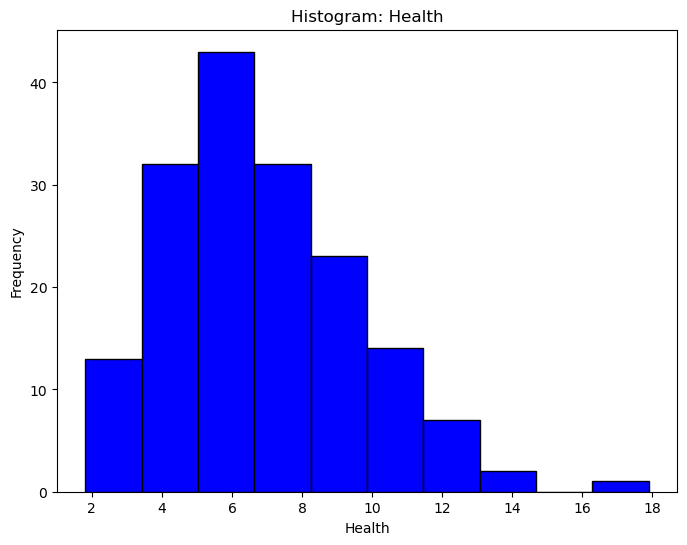

In [3]:
plt.figure(figsize=(8, 6))
plt.hist(df['health'], bins=10, color='blue', edgecolor='black')
plt.title("Histogram: Health")
plt.xlabel("Health")
plt.ylabel("Frequency")
plt.show()

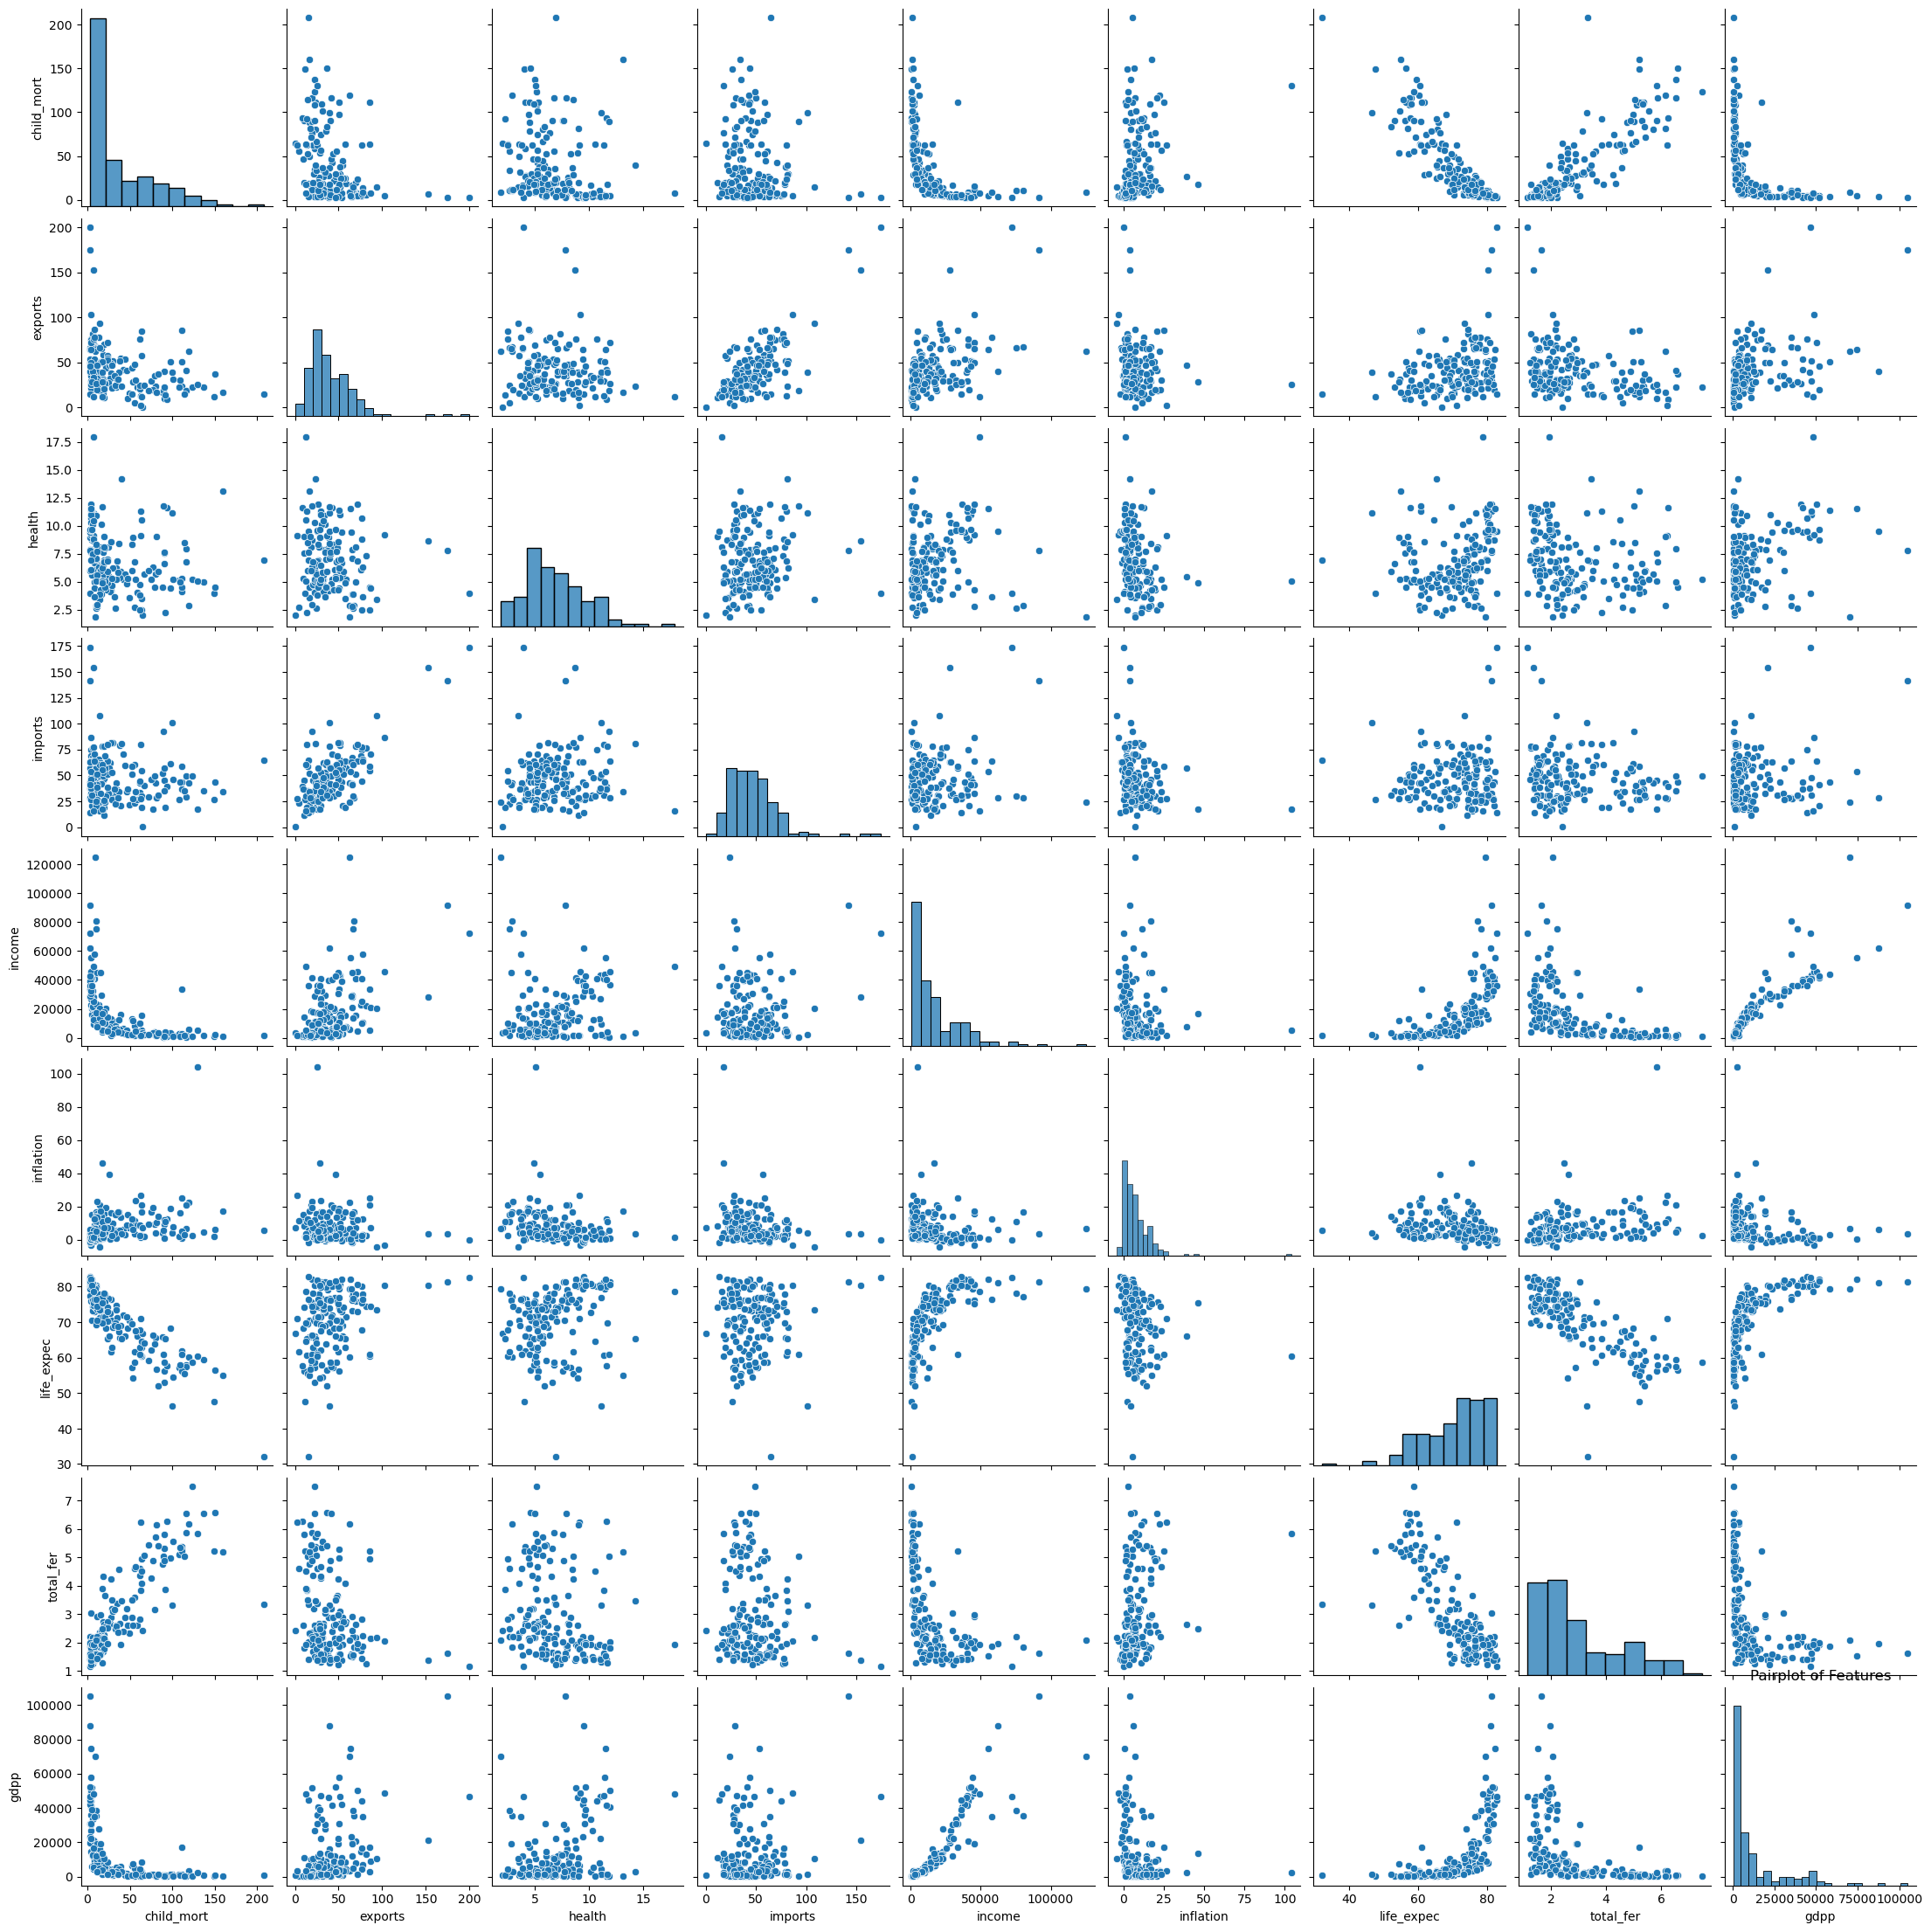

In [4]:
sns.pairplot(df)
plt.title("Pairplot of Features")
plt.show()

/home/ameermmdd/anaconda3/lib/python3.10/site-packages/seaborn/utils.py:159: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  scout = method([], [], **kws)


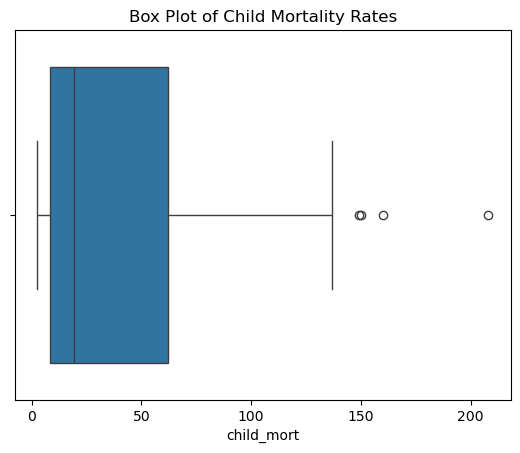

In [5]:
sns.boxplot(x='child_mort', data=df)
plt.title('Box Plot of Child Mortality Rates')
plt.show()

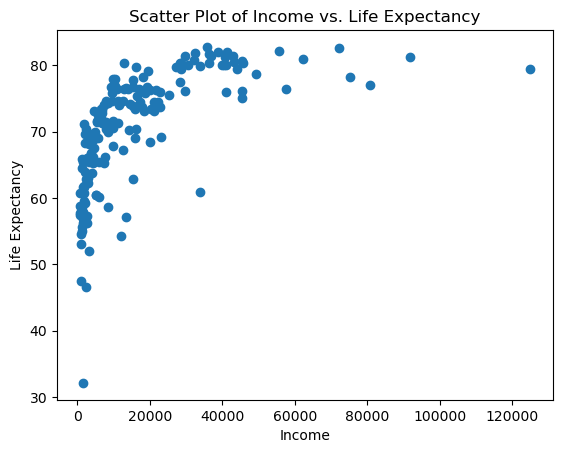

In [6]:
plt.scatter(df['income'], df['life_expec'])
plt.xlabel('Income')
plt.ylabel('Life Expectancy')
plt.title('Scatter Plot of Income vs. Life Expectancy')
plt.show()

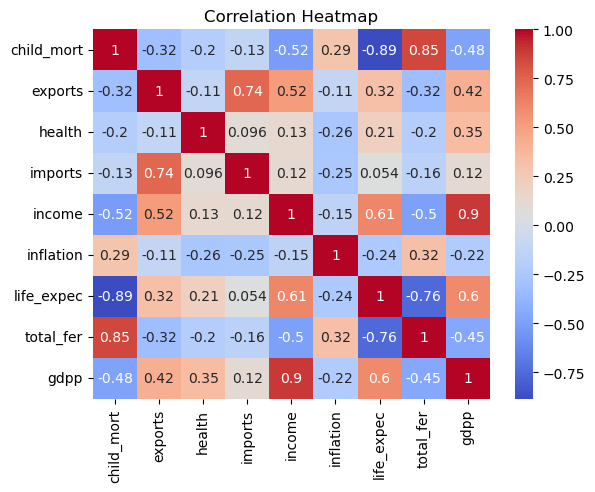

In [7]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


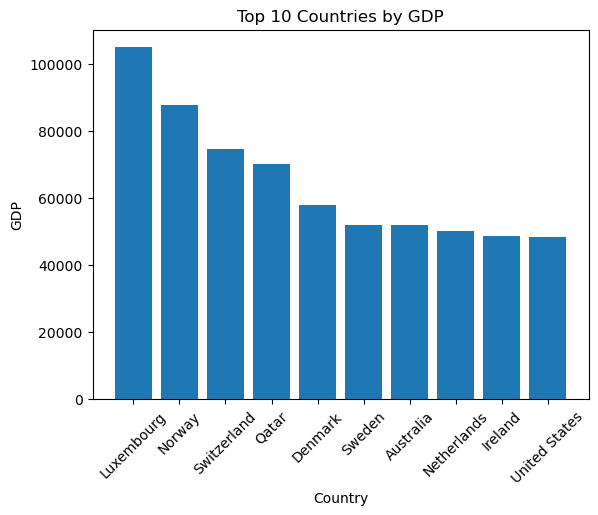

In [8]:
top10_gdp = df.nlargest(10, 'gdpp')
plt.bar(top10_gdp['country'], top10_gdp['gdpp'])
plt.xlabel('Country')
plt.ylabel('GDP')
plt.title('Top 10 Countries by GDP')
plt.xticks(rotation=45)
plt.show()

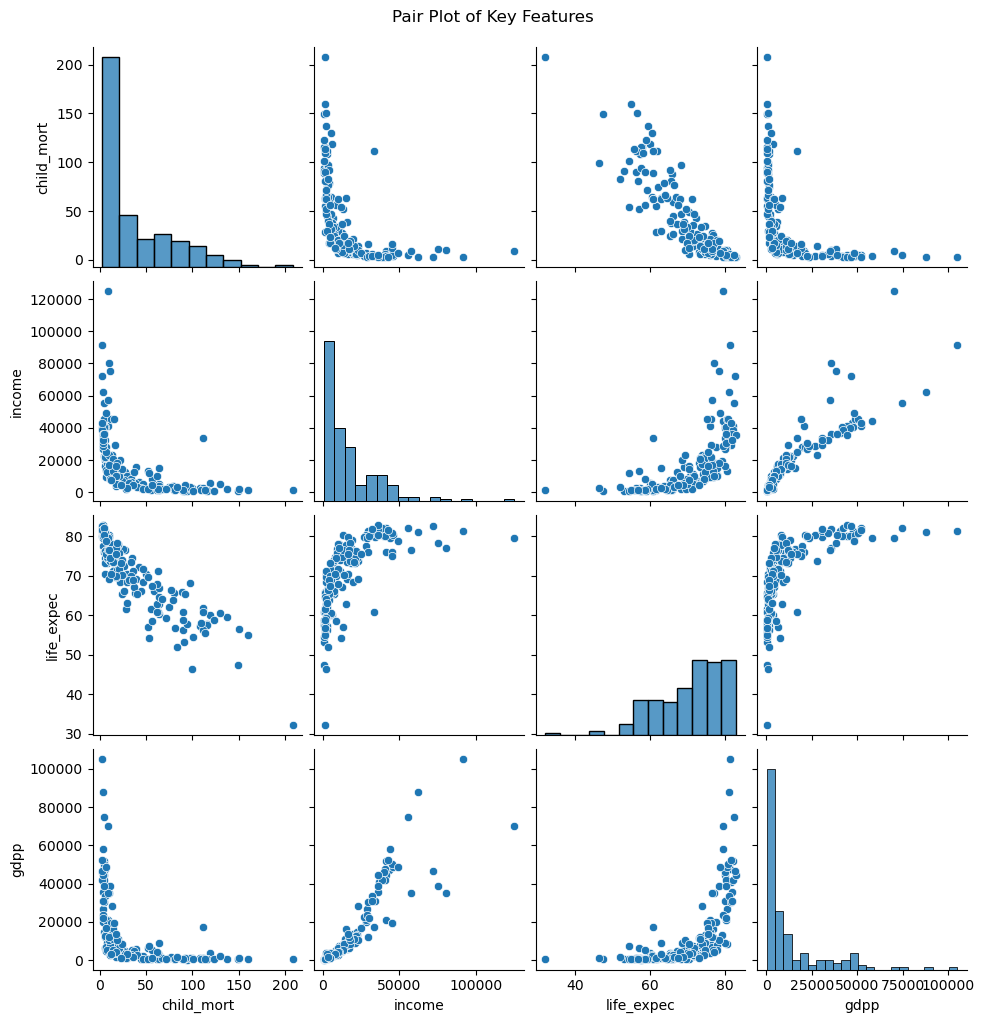

In [9]:
sns.pairplot(df[['child_mort', 'income', 'life_expec', 'gdpp']])
plt.suptitle('Pair Plot of Key Features', y=1.02)
plt.show()

### PCA

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
داده های خود را با استفاده از الگوریتم PCA به 2 بعد کاهش دهید.دقت کنید که به داده های اصلی نیاز داریم. پس حتما آن ها را ذخیره کنید.
</font>
</p>
</div>

/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Che

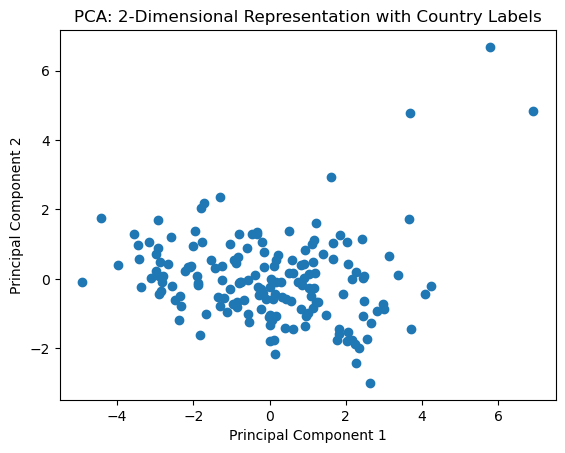

In [10]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt  # Added import for plotting

# Selecting numerical columns for PCA
selected_columns = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
data_subset = df[selected_columns]

# Standardize the features
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(data_subset)

# PCA
pca_model = PCA(n_components=2)
transformed_data = pca_model.fit_transform(scaled_data)

# Create a DataFrame for the reduced data
pca_result_df = pd.DataFrame(data=transformed_data, columns=['PC1', 'PC2']).astype(np.float32)

# Scatter plot to demonstrate new features
plt.scatter(pca_result_df['PC1'], pca_result_df['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: 2-Dimensional Representation with Country Labels')
plt.show()


## Clustering

### Similarity

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> در این مرحله نیاز است که ماتریس شباهت دادگان را به دست آورید.برای هر یک از داده ها برداری از ویژگی هایش را در نظر گرفته  و ماتریس شباهت رابرای کل  دیتاست به دست آورید.برای معیار شباهت نیز یک بار از فاصله اقلیدسی و یک بار از شباهت کوسینوسی کمک بگیرید.
این کار را هم برای داده های کاهش داده شده و هم برای داده های اصلی انجام دهید.
</font>
</p>
</div> 

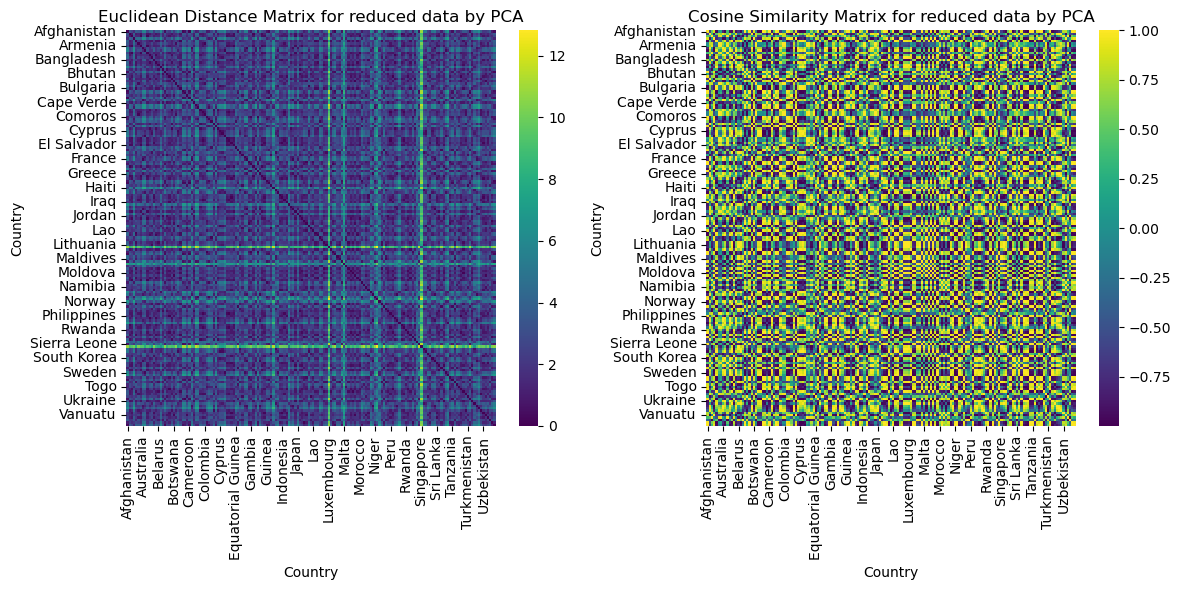

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already performed PCA and have pca_result_df as a DataFrame

X_pca_result = pca_result_df[['PC1', 'PC2']]

# Euclidean distances
euclidean_distance_matrix = euclidean_distances(X_pca_result)

# Cosine similarities
cosine_similarity_matrix = cosine_similarity(X_pca_result)

euclidean_distance_df = pd.DataFrame(euclidean_distance_matrix, index=df['country'], columns=df['country'])
cosine_similarity_df = pd.DataFrame(cosine_similarity_matrix, index=df['country'], columns=df['country'])

# Set up the figure
plt.figure(figsize=(12, 6))

# Plot Euclidean Similarity Matrix
plt.subplot(1, 2, 1)
sns.heatmap(euclidean_distance_df, cmap="viridis")
plt.title("Euclidean Distance Matrix for reduced data by PCA")
plt.xlabel("Country")
plt.ylabel("Country")

# Plot Cosine Similarity Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cosine_similarity_df, cmap="viridis")
plt.title("Cosine Similarity Matrix for reduced data by PCA")
plt.xlabel("Country")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Che

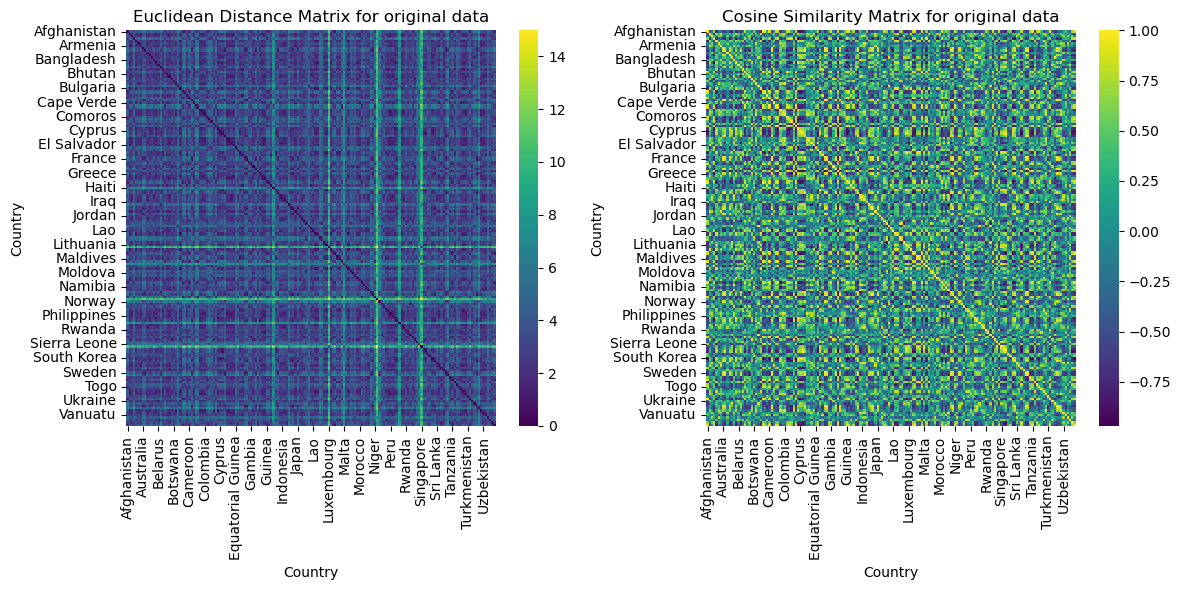

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

similarity_columns = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
data_subset = df[similarity_columns]

# Standardize the features
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(data_subset)

# Euclidean distances
euclidean_distance_matrix = euclidean_distances(scaled_data)

# Cosine similarities
cosine_similarity_matrix = cosine_similarity(scaled_data)

euclidean_distance_df = pd.DataFrame(euclidean_distance_matrix, index=df['country'], columns=df['country'])
cosine_similarity_df = pd.DataFrame(cosine_similarity_matrix, index=df['country'], columns=df['country'])

# Set up the figure
plt.figure(figsize=(12, 6))

# Plot Euclidean Similarity Matrix
plt.subplot(1, 2, 1)
sns.heatmap(euclidean_distance_df, cmap="viridis")
plt.title("Euclidean Distance Matrix for original data")
plt.xlabel("Country")
plt.ylabel("Country")

# Plot Cosine Similarity Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cosine_similarity_df, cmap="viridis")
plt.title("Cosine Similarity Matrix for original data")
plt.xlabel("Country")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


### Kmeans

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> بعد از پیاده سازی ماتریش شباهت باید در این مرحله الگوریتم Kmeans را پیاده سازی کنید.دقت کنید استفاده از 
    .
کتابخانه های  آماده مجاز نیست. همچنین مراکز اولیه باید به صورت تصادفی انتخاب شود و تعداد خوشه ها را نیز به صورت بهینه انتتخاب کنید
الگوریتم را تا  زمانی ادامه دهید که به دقت مناسبی برسد.
دقت کنید مجدد خوشه بندی را برای هر دو داده کاهش داده شده و اصلی باید انجام دهید.
</font>
</p>
</div> 

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random centroids for k-means
def initialize_centroids(num_features, k):
    centroids = np.random.rand(k, num_features)
    return centroids
    
# Check for convergence based on changes in centroids
def check_convergence(old_centroids, centroids, iterations, max_iterations=100, threshold=1e-4):
    if iterations >= max_iterations:
        return True
    if old_centroids is not None:
        return np.linalg.norm(centroids - old_centroids) < threshold
    return False

# Assign labels to data points based on centroids
def assign_labels(data, centroids):
    labels = []
    # Iterate over each data point 
    for index, point in data.iterrows():
        # Calculate distances between the current data point and all centroids
        distances = [np.linalg.norm(point - centroid) for centroid in centroids]
        # Assign the label of the closest centroid to the current data point
        label = np.argmin(distances)
        labels.append(label)
    return np.array(labels)

# Update centroids based on assigned labels
def update_centroids(labels, dataset, k):
    centroids = []
    for i in range(k):
        cluster_points = dataset[labels == i]
        if len(cluster_points) > 0:
            centroids.append(cluster_points.mean(axis=0))
        else:
            centroids.append(np.zeros(cluster_points.shape[1]))
    return np.array(centroids)
    
# Perform k-means clustering
def k_means_clustering(dataset, k):
    num_features = dataset.shape[1]
    centroids = initialize_centroids(num_features, k)

    iterations = 0
    old_centroids = None
    # Iterate until convergence
    while not check_convergence(old_centroids, centroids, iterations):
        old_centroids = centroids
        iterations += 1
        labels = assign_labels(dataset, centroids)
        centroids = update_centroids(labels, dataset, k)
    return centroids
    
# Perform elbow method to find optimal k
def elbow_method(data, max_k):
    wcss_values = []
    for k in range(1, max_k + 1):
        centroids = k_means_clustering(data, k)
        labels = assign_labels(data, centroids)        
        wcss_values.append(np.sum((data.values - centroids[labels])**2))
    plt.plot(range(1, max_k + 1), wcss_values)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('(WCSS)')
    plt.title('Elbow Method for Optimal k')
    plt.show()


### Results

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> 
در این مرحله نیاز است که نموداری بر اساس خوشه های خود همچنین دقت الگوریتم خود را به صورت نمودار و عددی نشان دهید.

</font>
</p>
</div> 

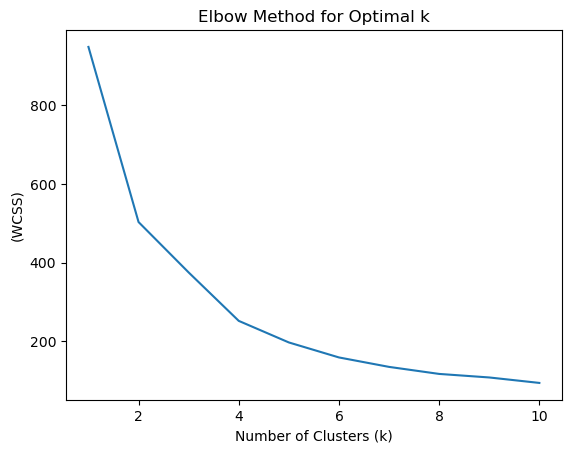

In [20]:
# Performing elbow method to find optimal k from plot
elbow_method(pca_result_df, 10)


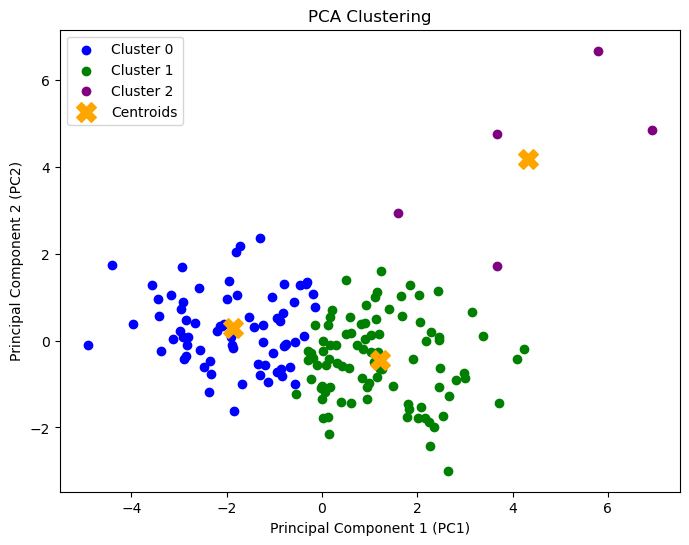

In [17]:
k_clusters = 3  # Number of clusters (determined from elbow method)
cluster_centroids = k_means_clustering(pca_result_df, k_clusters)

# Assign labels to data points based on the centroids
pca_labels = assign_labels(pca_result_df, cluster_centroids)

# Set custom colors for clusters
cluster_colors = ['blue', 'green', 'purple']

# Create a scatter plot
plt.figure(figsize=(8, 6))
for label, color in zip(range(k_clusters), cluster_colors):
    indices = np.where(pca_labels == label)[0]
    plt.scatter(pca_result_df.iloc[indices, 0], pca_result_df.iloc[indices, 1], label=f'Cluster {label}', color=color)

# Plot centroids in a different color
plt.scatter(cluster_centroids[:, 0], cluster_centroids[:, 1], marker='X', s=200, c='orange', label='Centroids')

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA Clustering')
plt.legend()
plt.show()


In [22]:
# Normalize features
# pca_cols are features which are numerical
df_normalized = df.copy() 
df_normalized[selected_columns] = data_scaler.fit_transform(df_normalized[selected_columns])
data = df_normalized[selected_columns] 

/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Che

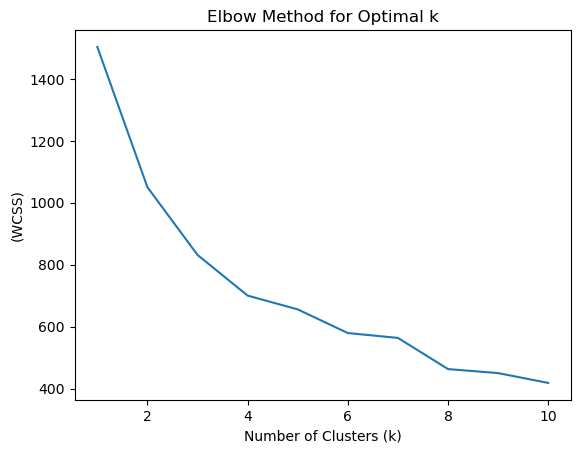

In [23]:
# Performing elbow metgod to find optimal k from plot
elbow_method(data,10)

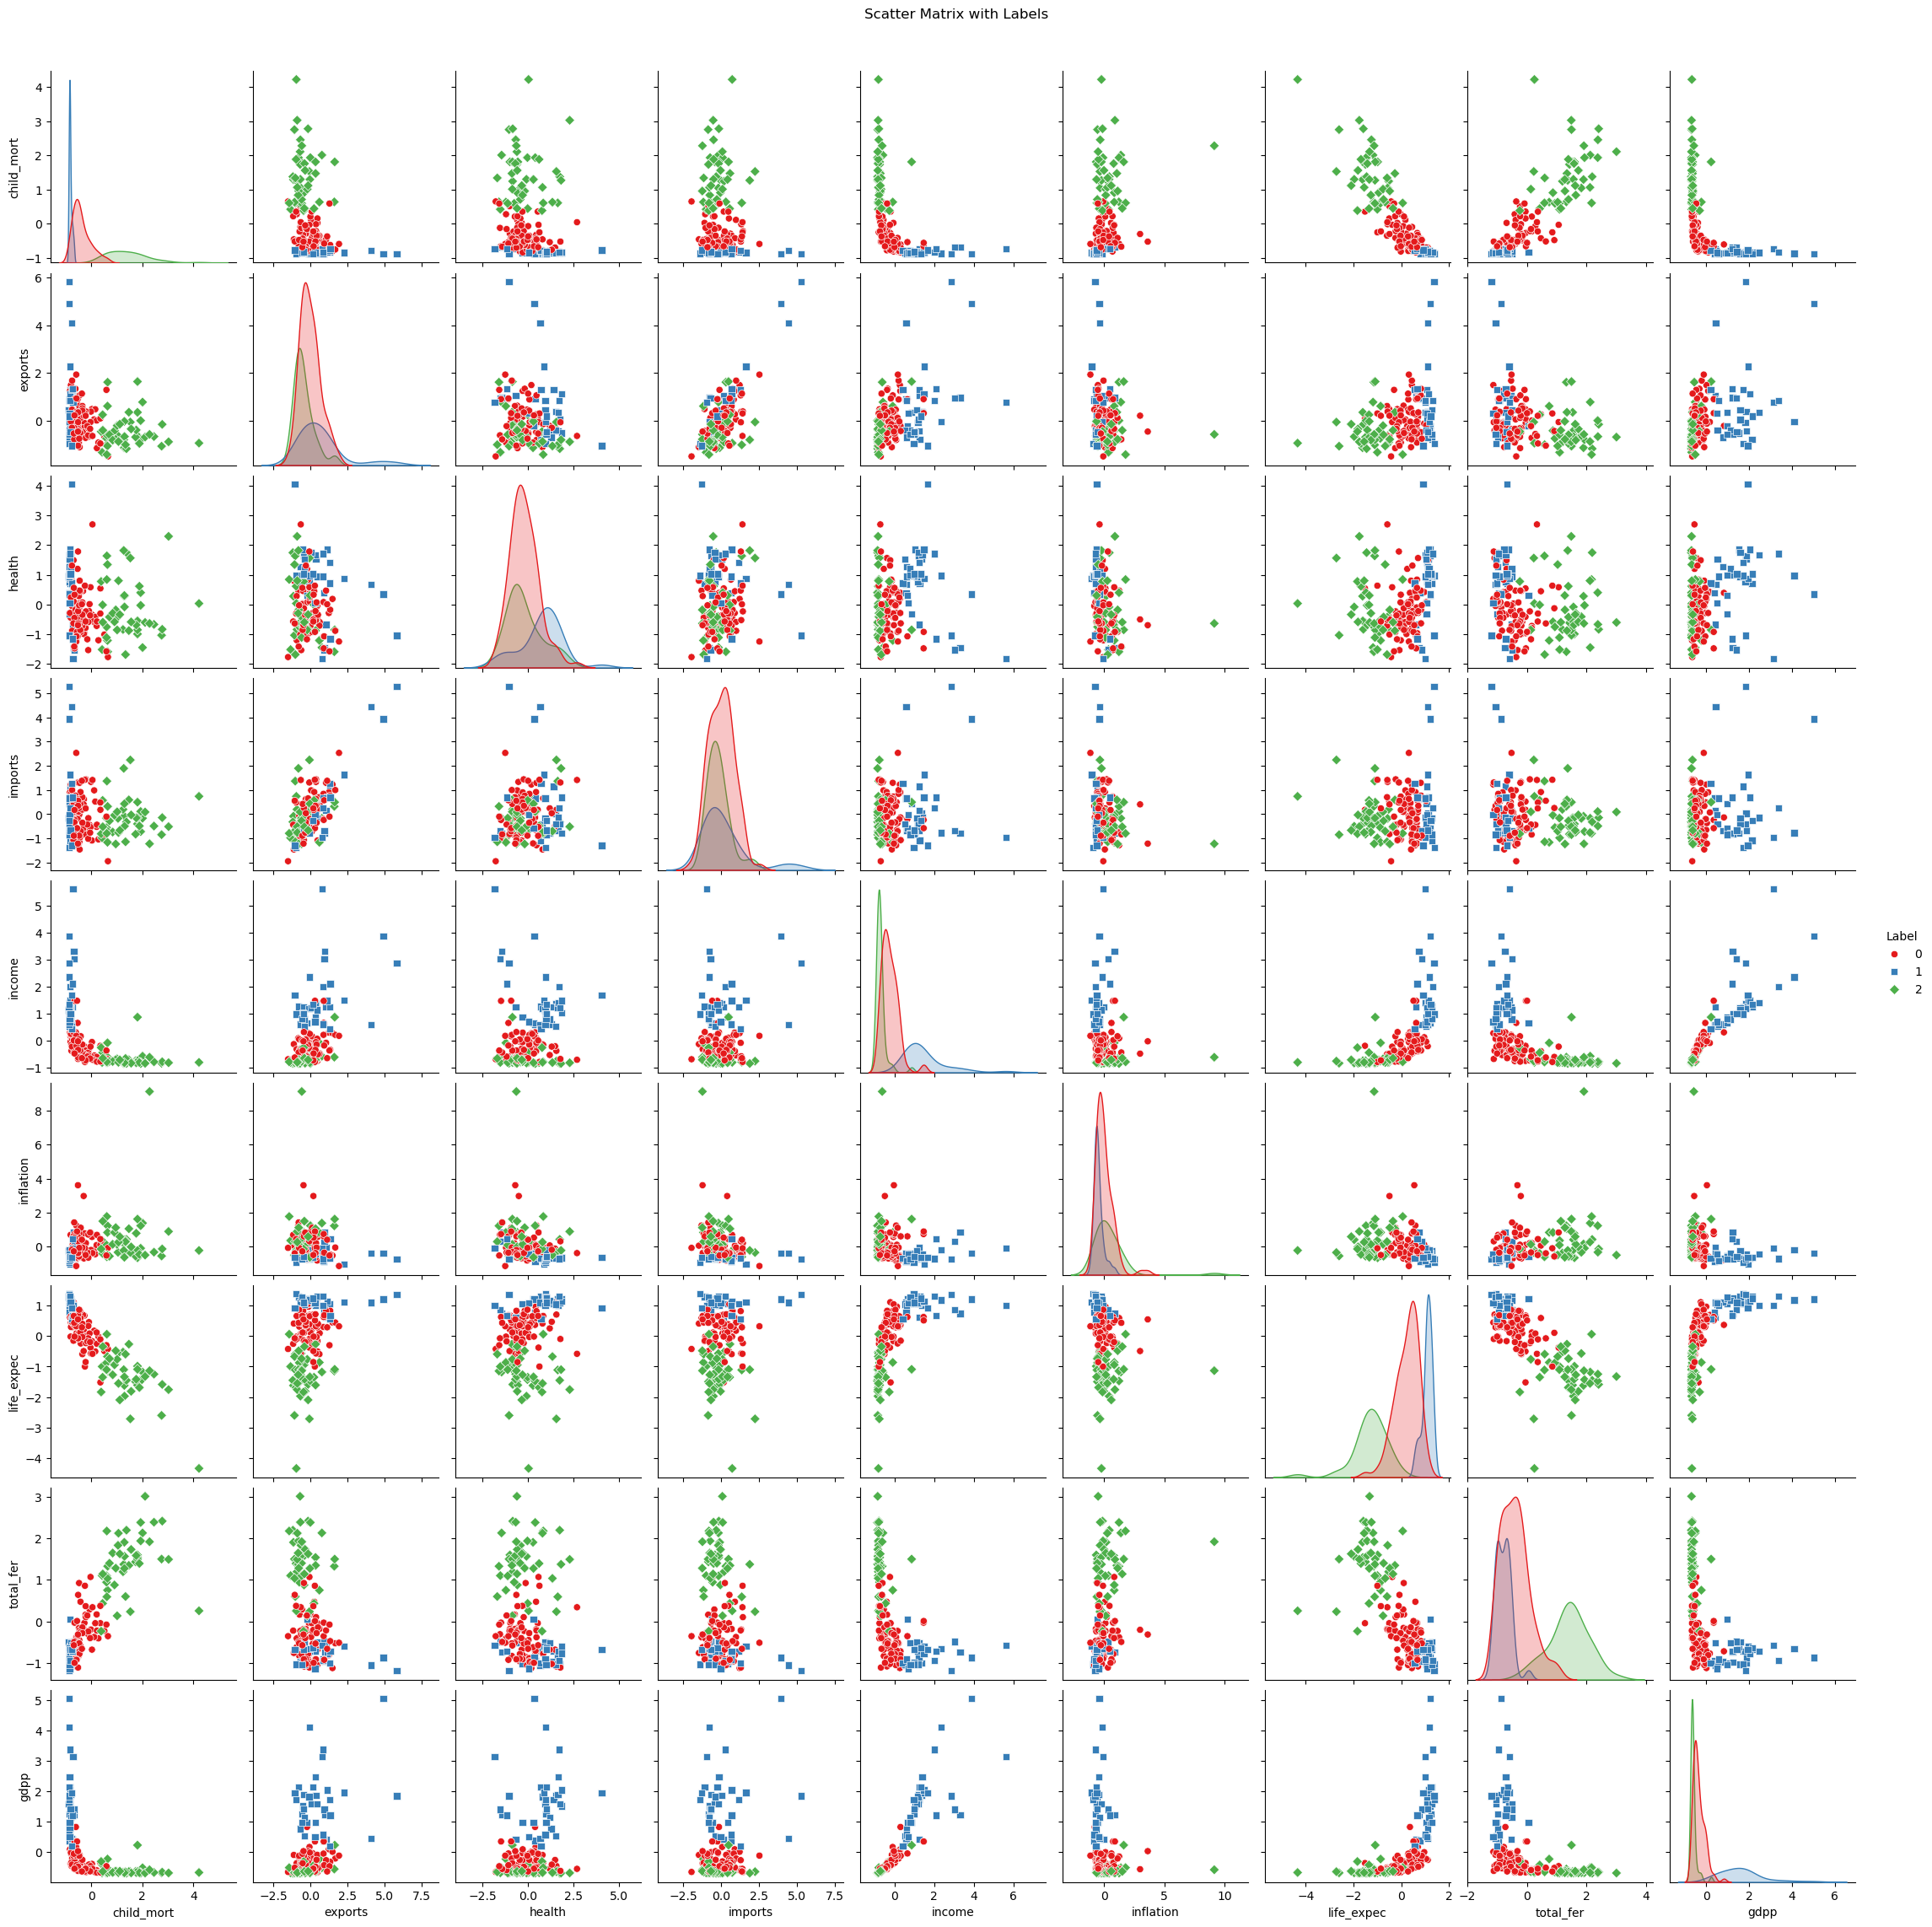

In [26]:
k = 3  # Number of clusters
# We want to make a comparison, so we choose the same k from k-means on PCA data
centroids = k_means_clustering(data, k)
original_data_output_labels = assign_labels(data, centroids)

data['Label'] = original_data_output_labels

# Scatter matrix with labels
sns.pairplot(data, vars=selected_columns, hue='Label', palette='Set1', markers=["o", "s", "D"])
plt.suptitle('Scatter Matrix with Labels', y=1.02)
plt.show()


<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> نتایج به دست آمده بالا را با یکدیگر مقایسه کرده و نتیجه را توجیه کنید.
</font>
</p>
</div> 

In [28]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_avg_pca_result = silhouette_score(pca_result_df, pca_labels)
silhouette_avg_original_data = silhouette_score(data, original_data_output_labels)

print("Silhouette Average for PCA result data: ", silhouette_avg_pca_result)
print("Silhouette Average for original data: ", silhouette_avg_original_data)


Silhouette Average for PCA result data:  0.4376503
Silhouette Average for original data:  0.34638525516184104


/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Che

The higher post-reduction score indicates the effectiveness of the PCA technique, demonstrating improved clustering with more distinct and well-defined features. Dimensionality reduction is a crucial method in data preprocessing that can significantly enhance clustering performance.

By eliminating unnecessary and redundant features, dimensionality reduction preserves the meaningful structure of the data, enhancing the ability to differentiate and distinguish between clusters. Additionally, reducing the number of dimensions decreases the computational complexity required for clustering algorithms, leading to increased efficiency and execution speed.

### DBSCAN

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> 
الگوریتم DBSCAN را بر هر دو داده کاهش داده شده و اصلی پساده سازی کنید.
    مجددا نمی توانید در اینجا از کتابخانه های آماده استفاده کنید.
</font>
</p>
</div>

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def find_min_pts(data):
    num_dimensions = data.shape[1]
    min_pts = num_dimensions + 1
    min_pts = max(min_pts, 3)
    return min_pts

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

def find_optimal_eps(data, min_pts):
    nbrs = NearestNeighbors(n_neighbors=min_pts, algorithm='auto').fit(data)
    distances, _ = nbrs.kneighbors(data)
    distances = np.sort(distances[:, -1])
    plt.plot(distances)
    plt.xlabel('Data Points')
    plt.ylabel(f'{min_pts}-Distance')
    plt.title(f'k-Distance Graph (MinPts={min_pts})')
    plt.show()

import numpy as np

def dbscan(df, eps, min_samples):
    labels = np.full(len(df), -1)
    cluster_id = 0

    for i, point in df.iterrows():
        if labels[i] != -1:
            continue

        neighbors = region_query(df, i, eps)
        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(df, labels, i, neighbors, cluster_id, eps, min_samples)

    return labels

def region_query(df, idx, eps):
    neighbors = []
    for i, point in df.iterrows():
        if np.linalg.norm(df.iloc[idx] - point) <= eps and i != idx:
            neighbors.append(i)
    return neighbors

def expand_cluster(df, labels, idx, neighbors, cluster_id, eps, min_samples):
    labels[idx] = cluster_id
    i = 0
    while i < len(neighbors):
        n = neighbors[i]
        if labels[n] == -1:
            labels[n] = cluster_id
            new_neighbors = region_query(df, n, eps)
            if len(new_neighbors) >= min_samples:
                neighbors.extend(new_neighbors)
        elif labels[n] == 0:
            labels[n] = cluster_id
        i += 1


### Results

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> 
در این مرحله نیاز است که نموداری بر اساس خوشه های خود همچنین دقت الگوریتم خود را به صورت نمودار و عددی نشان دهید.
همچنین مقادری بهینه minpts و eps را گزارش کنید.
</font>
</p>
</div> 

/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Che

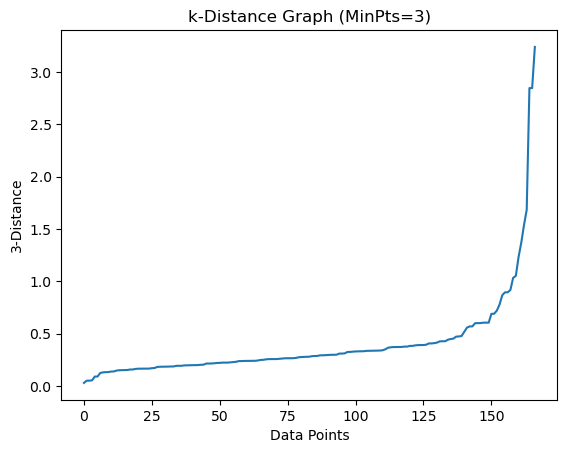

MinPts =  3
Optimal eps =  0.6


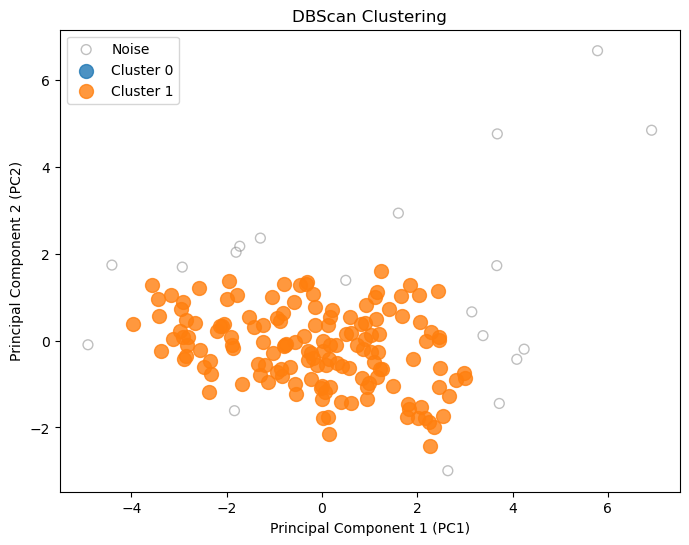

In [32]:
# # Find optimal eps and MinPts
# min_pts = find_min_pts(pca_result_df)
# find_optimal_eps(pca_result_df, min_pts)
# eps = 0.6
# print("MinPts = ", min_pts)
# print("Optimal eps = ", eps)

# # Perform DBScan
# dbscan_pca_output_labels = dbscan(pca_result_df, eps=eps, min_samples=min_pts)

# # Prepare Plot
# plt.figure(figsize=(8, 6))
# k = len(np.unique(dbscan_pca_output_labels))

# # Find indices of noise data
# noise_indices = [i for i, label in enumerate(dbscan_pca_output_labels) if label == -1]
# plt.scatter(
#     pca_result_df.iloc[noise_indices, 0], pca_result_df.iloc[noise_indices, 1],
#     label='Noise', facecolor='none', color='gray', marker='o', s=50, alpha=0.5
# )

# for label in range(k):
#     if label != -1:
#         indices = [i for i, x in enumerate(dbscan_pca_output_labels) if x == label]
#         plt.scatter(
#             pca_result_df.iloc[indices, 0], pca_result_df.iloc[indices, 1],
#             label=f'Cluster {label}', s=100, alpha=0.8
#         )

# plt.xlabel('Principal Component 1 (PC1)')
# plt.ylabel('Principal Component 2 (PC2)')
# plt.title('DBScan Clustering')
# plt.legend()
# plt.show()
# Find optimal eps and MinPts
min_pts = find_min_pts(pca_result_df)
find_optimal_eps(pca_result_df, min_pts)
eps = 0.6
print("MinPts = ", min_pts)
print("Optimal eps = ", eps)

# Perform DBScan
dbscan_pca_output_labels = dbscan(pca_result_df, eps=eps, min_samples=min_pts)

# Prepare Plot
plt.figure(figsize=(8, 6))
k = len(np.unique(dbscan_pca_output_labels))

# Find indices of noise data
noise_indices = [i for i, label in enumerate(dbscan_pca_output_labels) if label == -1]
plt.scatter(
    pca_result_df.iloc[noise_indices, 0], pca_result_df.iloc[noise_indices, 1],
    label='Noise', facecolor='none', color='gray', marker='o', s=50, alpha=0.5
)

for label in range(k):
    if label != -1:
        indices = [i for i, x in enumerate(dbscan_pca_output_labels) if x == label]
        plt.scatter(
            pca_result_df.iloc[indices, 0], pca_result_df.iloc[indices, 1],
            label=f'Cluster {label}', s=100, alpha=0.8
        )

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('DBScan Clustering')
plt.legend()
plt.show()


/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Che

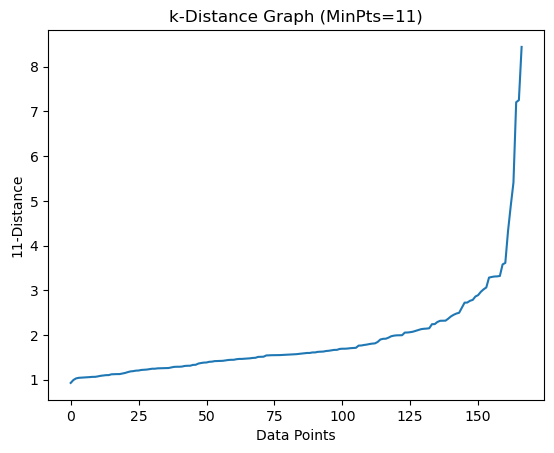

MinPts =  11
Optimal eps =  2


/home/ameermmdd/anaconda3/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/ameermmdd/anaconda3/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/ameermmdd/anaconda3/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/ameermmdd/anaconda3/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  func(x=vector, **plot_kwargs)
/home/ameermmdd/anaconda3/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: The palette list has more values (5) than needed (3), which may not be intende

<Figure size 1000x800 with 0 Axes>

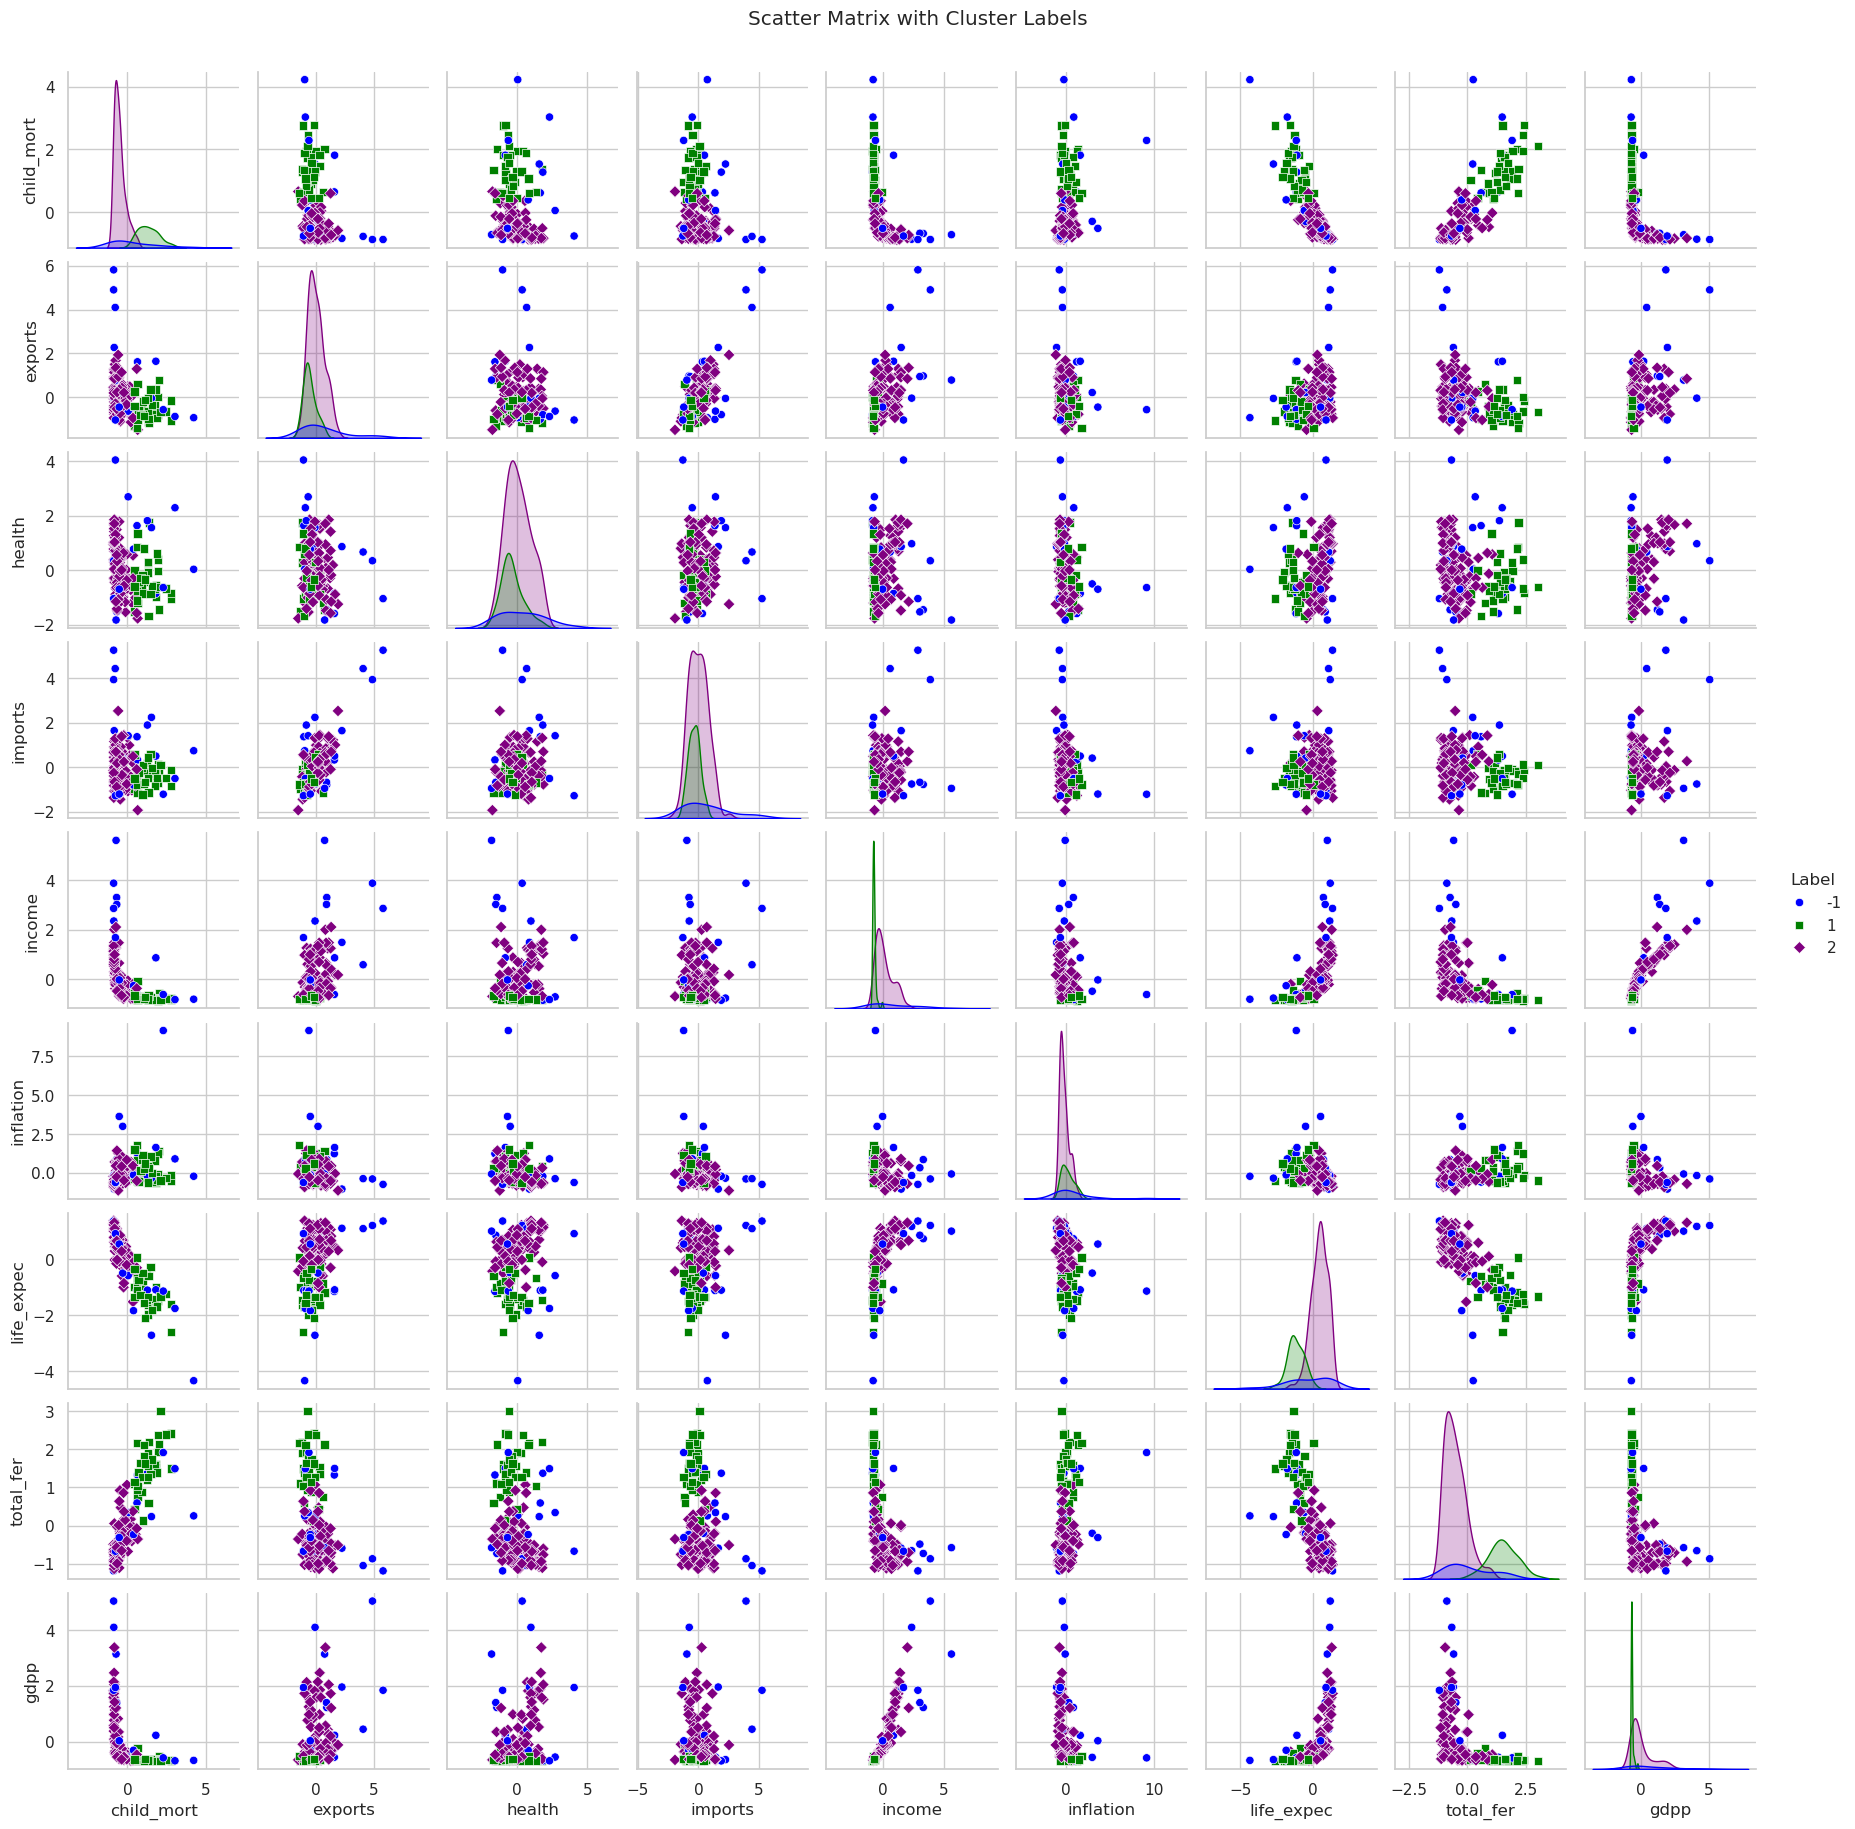

In [34]:
# Find optimal eps and MinPts
min_pts = find_min_pts(data)
find_optimal_eps(data, min_pts)
eps = 2
print("MinPts = ", min_pts)
print("Optimal eps = ", eps)

# Perform DBScan
dbscan_data_output_labels = dbscan(data, eps=eps, min_samples=min_pts)

# Prepare Scatter Matrix
plt.figure(figsize=(10, 8))
data_copy = data.copy()
data_copy['Label'] = dbscan_data_output_labels

# Customizing the appearance
colors = ['blue', 'green', 'purple', 'orange', 'red']  # Add more colors if needed
markers = ['o', 's', 'D', '^', 'v']  # Add more markers if needed

sns.set_palette(colors)
sns.set(style="whitegrid")
scatter_matrix = sns.pairplot(data_copy, hue='Label', markers=markers, palette=colors, diag_kind='kde', height=2)

# Customizing the titles and labels
scatter_matrix.fig.suptitle('Scatter Matrix with Cluster Labels', y=1.02)
plt.show()


In [35]:
from sklearn.metrics import silhouette_samples
from sklearn.cluster import DBSCAN
import numpy as np

def dbscan_silhouette_score(X,cluster_labels, eps, min_samples):

    # Calculate silhouette score for each sample
    silhouette_scores = silhouette_samples(X, cluster_labels)
    
    # Exclude noise points from the calculation
    core_points_mask = cluster_labels != -1
    core_points_silhouette_scores = silhouette_scores[core_points_mask]
    
    # Compute the overall silhouette score
    overall_silhouette_score = np.mean(core_points_silhouette_scores)
    return overall_silhouette_score



In [37]:
print("dbscan silhouette score for PCA data: ",dbscan_silhouette_score(pca_result_df,dbscan_pca_output_labels,1.5,3))
print("dbscan silhouette score for original data: ",dbscan_silhouette_score(data,dbscan_data_output_labels,1.5,11))


dbscan silhouette score for PCA data:  0.4678099
dbscan silhouette score for original data:  0.4219737750924689


/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/home/ameermmdd/.local/lib/python3.10/site-packages/pandas/core/algorithms.py:1814: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Che

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> 
نتایج به دست آمده از مرحله قبل را با این مرحله مقایسه کرده و علت بهتر بودن الگوریتم بهینه را توجیه کنید
</font>
</p>
</div> 

On one hand, we observe higher scores compared to k-means. In this algorithm, clusters exhibit higher density compared to k-means. In DBScan, noise points are eliminated, leading to an improvement in the clustering quality. As evident in the examples, the data within the resulting clusters is more uniform and cohesive.
In contrast, in k-means, noise points can become part of a cluster, indicating the algorithm's lack of precision and robustness in handling outliers.







## Association rules

<div dir="rtl">

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> 
در این مرحله باید هر دو دیتا ست داده شده به شما را خوانده و سپس برای محموعه داده کوچکتر آستانه پشتیبانی و آستانه اطمینان را به صورت ورودی از کاربر گرفته و سپس تمام قوانین انجمنی معتبر را برای آن ها به دست آورید.
    برای مجموعه داده های بزرگتر نیز مجدد آستانه پشتنیبانی و اطمینان را دریافت کرده و 3 کالایی که بیشترین خرید را با هم داشته اند به دست آورید.
</font>
</p>
</div> 

In [38]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Reading the first dataframe
data = pd.read_csv('Grocery Products Purchase.csv', header=None)

# Preprocessing the data
transactions = data.apply(lambda x: x.dropna().tolist(), axis=1).tolist()
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Finding frequent itemsets
frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True)

print(frequent_itemsets)

# Generating association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

# Filtering rules based on minimum confidence (adjust min_threshold as needed)
min_confidence = 0.05
filtered_rules = rules[rules['confidence'] >= min_confidence]

print("Association Rules with Confidence >= {}: ".format(min_confidence))
print(filtered_rules)


     support                        itemsets
0   0.052460                          (beef)
1   0.080521                  (bottled beer)
2   0.110512                 (bottled water)
3   0.064864                   (brown bread)
4   0.055409                        (butter)
5   0.077674                   (canned beer)
6   0.082757                  (citrus fruit)
7   0.058052                        (coffee)
8   0.053274                          (curd)
9   0.063440                 (domestic eggs)
10  0.058967                   (frankfurter)
11  0.072285         (fruit/vegetable juice)
12  0.058560                     (margarine)
13  0.052359                       (napkins)
14  0.079809                    (newspapers)
15  0.193473              (other vegetables)
16  0.088959                        (pastry)
17  0.075641                     (pip fruit)
18  0.057645                          (pork)
19  0.183916                    (rolls/buns)
20  0.108987               (root vegetables)
21  0.0939

In [39]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Reading the second dataframe
data_store = pd.read_csv('GroceryStoreDataSet.csv', header=None)

# Preprocessing the data
transactions_store = data_store.apply(lambda x: x.dropna().tolist(), axis=1).tolist()
te_store = TransactionEncoder()
te_ary_store = te_store.fit(transactions_store).transform(transactions_store)
df_store = pd.DataFrame(te_ary_store, columns=te_store.columns_)

# Finding frequent itemsets
frequent_itemsets_store = apriori(df_store, min_support=0.05, use_colnames=True)

print(frequent_itemsets_store)

# Generating association rules
rules = association_rules(frequent_itemsets_store, metric="confidence", min_threshold=0.05)

# Filtering rules based on minimum confidence (adjust min_threshold as needed)
min_confidence = 0.05
filtered_rules = rules[rules['confidence'] >= min_confidence]

print("Association Rules with Confidence >= {}: ".format(min_confidence))
print(filtered_rules)

    support                          itemsets
0      0.05               (BREAD,COFFEE,COCK)
1      0.10              (BREAD,COFFEE,SUGER)
2      0.05                      (BREAD,MILK)
3      0.05   (BREAD,MILK,BISCUIT,CORNFLAKES)
4      0.05             (BREAD,SUGER,BISCUIT)
5      0.05           (BREAD,SUGER,BOURNVITA)
6      0.10             (BREAD,TEA,BOURNVITA)
7      0.10  (COFFEE,COCK,BISCUIT,CORNFLAKES)
8      0.05          (COFFEE,SUGER,BOURNVITA)
9      0.05         (COFFEE,SUGER,CORNFLAKES)
10     0.05            (JAM,MAGGI,BREAD,MILK)
11     0.05             (JAM,MAGGI,BREAD,TEA)
12     0.05         (MAGGI,BREAD,TEA,BISCUIT)
13     0.05               (MAGGI,TEA,BISCUIT)
14     0.05            (MAGGI,TEA,CORNFLAKES)
15     0.05              (MILK,BREAD,BISCUIT)
16     0.05      (TEA,MILK,COFFEE,CORNFLAKES)
Association Rules with Confidence >= 0.05: 
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage,